In [1]:
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
import torch
from loss.flexible_dilate_loss import dilate_loss
import temporal_penalties as tp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

T = 30
t = torch.arange(1, T+1).float().view(-1,1).to(device)

Omega_l1 = tp.pairwise_distances_l1(t, t)
Omega_l2 = tp.pairwise_distances_l2(t, t)
Omega_huber = tp.pairwise_distances_huber(t, t)
Omega_asym = tp.pairwise_temporal_asymmetric(t, t)

# Fake dataset
x = torch.sin(torch.linspace(0, 6, T))
x = x.view(1,T,1).to(device)
x_pred = x.roll(1, dims=1)  # naive shifted predictor

for name, Omega in [
    ("L1", Omega_l1),
    ("L2", Omega_l2),
    ("Huber", Omega_huber),
    ("Asymmetric", Omega_asym)
]:
    loss, l_shape, l_temp = dilate_loss(x_pred, x, 0.5, 0.01, device, Omega)
    print(f"{name} -> total={loss.item():.4f}, shape={l_shape.item():.4f}, temporal={l_temp.item():.4f}")


L1 -> total=0.0056, shape=-0.0317, temporal=0.0428
L2 -> total=0.0132, shape=-0.0317, temporal=0.0581
Huber -> total=-0.0034, shape=-0.0317, temporal=0.0249
Asymmetric -> total=0.0705, shape=-0.0317, temporal=0.1728


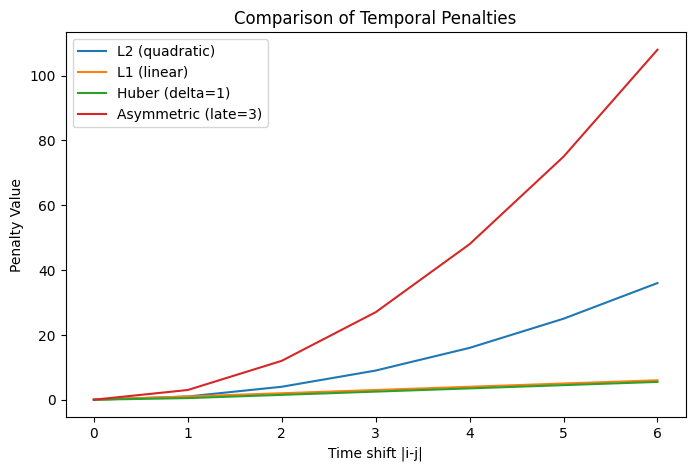

In [7]:
# ============================================================
# 4) PLOT PENALTY SHAPES
# ============================================================

shifts = torch.arange(0,7).float()

plt.figure(figsize=(8,5))
plt.plot(shifts, shifts**2, label="L2 (quadratic)")
plt.plot(shifts, shifts, label="L1 (linear)")
huber = torch.where(shifts<=1.0,0.5*shifts**2,1.0*(shifts-0.5))
plt.plot(shifts, huber, label="Huber (delta=1)")
plt.plot(shifts, 3*(shifts**2), label="Asymmetric (late=3)")
plt.xlabel("Time shift |i-j|")
plt.ylabel("Penalty Value")
plt.title("Comparison of Temporal Penalties")
plt.legend()
plt.show()


| Reason                   | Then use       |
| ------------------------------------- | -------------- |
| Time matters a lot                 | **L2**         |
| Shape matters more than time            | **L1**         |
| Time matters locally but don’t panic          | **Huber**      |
| Being late is dangerous / expensive | **Asymmetric** |


==== Comparison ====
MSE Loss             : 0.3008
DILATE Loss          : 0.0107
 - Shape component   : -0.0532
 - Temporal component: 0.0746


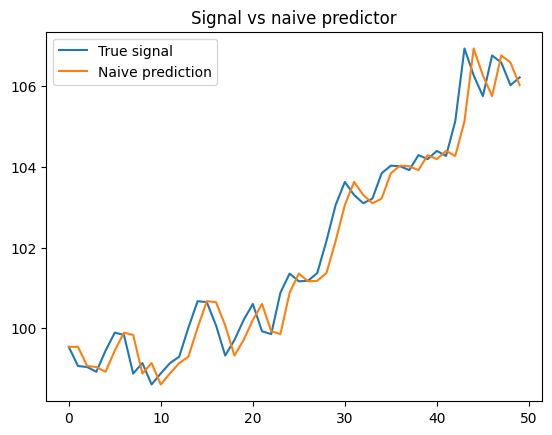

In [3]:
import torch
import matplotlib.pyplot as plt
from loss.dilate_loss import dilate_loss  # your function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- 1. Simulate a price time series -----
torch.manual_seed(0)
T = 50
signal = torch.cumsum(torch.randn(T) * 0.5 + 0.1, dim=0) + 100  # random walk around 100
signal = signal.view(1, T, 1).to(device)  # (batch=1, seq, dim)

# ----- 2. Naive predictor: x_hat(t) = x(t-1) -----
naive_pred = torch.zeros_like(signal)
naive_pred[:, 1:, :] = signal[:, :-1, :]  # shift right by 1
naive_pred[:, 0, :] = signal[:, 0, :]     # copy first value

# ----- 3. Compute MSE -----
mse = torch.mean((signal - naive_pred) ** 2)

# ----- 4. Compute DILATE -----
alpha = 0.5
gamma = 0.01
loss, loss_shape, loss_temporal = dilate_loss(naive_pred, signal, alpha, gamma, device)

# ----- 5. Print results -----
print("==== Comparison ====")
print(f"MSE Loss             : {mse.item():.4f}")
print(f"DILATE Loss          : {loss.item():.4f}")
print(f" - Shape component   : {loss_shape.item():.4f}")
print(f" - Temporal component: {loss_temporal.item():.4f}")

# ----- 6. Plot -----
plt.plot(signal.cpu().numpy().flatten(), label='True signal')
plt.plot(naive_pred.cpu().numpy().flatten(), label='Naive prediction')
plt.legend()
plt.title("Signal vs naive predictor")
plt.show()
